In [9]:
# ============================================================
# CLUTCH PLAYER PERFORMANCE MODEL
# Phase 2: Data Loading & Cleaning
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_theme(style="whitegrid")

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [10]:
# ============================================================
# Load all 5 seasons and combine into one DataFrame
# ============================================================

season_files = {
    '2019': 'pbp2019.csv',
    '2020': 'pbp2020.csv',
    '2021': 'pbp2021.csv',
    '2022': 'pbp2022.csv',
    '2023': 'pbp2023.csv',
}

dfs = []

for season, filename in season_files.items():
    print(f"Loading {filename}...")
    temp = pd.read_csv(filename)
    temp['season'] = season       # Tag each row with its season
    dfs.append(temp)
    print(f"  ✅ {len(temp):,} rows")

# Combine all seasons
df_raw = pd.concat(dfs, ignore_index=True)

print(f"\n✅ Combined dataset: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")

Loading pbp2019.csv...
  ✅ 592,551 rows
Loading pbp2020.csv...
  ✅ 571,014 rows
Loading pbp2021.csv...
  ✅ 570,306 rows
Loading pbp2022.csv...
  ✅ 645,450 rows
Loading pbp2023.csv...
  ✅ 646,367 rows

✅ Combined dataset: 3,025,688 rows × 16 columns


In [11]:
# ============================================================
# Understand what we're working with
# ============================================================

print("=== Column Names ===")
print(df_raw.columns.tolist())

print("\n=== First 5 Rows ===")
df_raw.head()

=== Column Names ===
['gameid', 'period', 'clock', 'h_pts', 'a_pts', 'team', 'playerid', 'player', 'type', 'subtype', 'result', 'x', 'y', 'dist', 'desc', 'season']

=== First 5 Rows ===


,gameid,period,clock,h_pts,a_pts,team,playerid,player,type,subtype,result,x,y,dist,desc,season
0,21800001,1,PT12M00.00S,0.0,0.0,NaN,0,NaN,period,start,NaN,0,0,0,Start of 1st Period (8:03 PM EST),2019
1,21800001,1,PT12M00.00S,NaN,NaN,BOS,201143,A. Horford,Jump Ball,NaN,NaN,0,0,0,Jump Ball Horford vs. Embiid: Tip to Simmons,2019
2,21800001,1,PT11M40.00S,NaN,NaN,PHI,203496,R. Covington,Missed Shot,Jump Shot,Missed,-53,264,27,MISS Covington 27' 3PT Jump Shot,2019
3,21800001,1,PT11M40.00S,NaN,NaN,NaN,1610612738,NaN,Rebound,Unknown,NaN,0,0,0,CELTICS Rebound,2019
4,21800001,1,PT11M15.00S,NaN,NaN,BOS,1628369,J. Tatum,Missed Shot,Jump Shot,Missed,-148,207,25,MISS Tatum 25' 3PT Jump Shot,2019


In [12]:
# ============================================================
# Filter to shots only (made + missed)
# ============================================================

print("All event types in dataset:")
print(df_raw['type'].value_counts().head(10))

# Keep only shot events
shots_df = df_raw[df_raw['type'].isin(['Made Shot', 'Missed Shot'])].copy()

print(f"\n✅ Shots only: {shots_df.shape[0]:,} rows")
print(f"   (Removed {df_raw.shape[0] - shots_df.shape[0]:,} non-shot events)")

All event types in dataset:
type
Rebound           644386
Missed Shot       581735
Made Shot         503904
Substitution      288252
Free Throw        279093
Foul              254754
Turnover          171725
Timeout            67525
period             49913
Instant Replay     10887
Name: count, dtype: int64

✅ Shots only: 1,085,639 rows
   (Removed 1,940,049 non-shot events)


In [15]:
# ============================================================
# FIXED: Keep & Clean shots properly
# ============================================================

cols = ['gameid', 'period', 'clock', 'h_pts', 'a_pts',
        'team', 'player', 'type', 'subtype', 'dist',
        'x', 'y', 'season']

shots_df = df_raw[df_raw['type'].isin(['Made Shot', 'Missed Shot'])].copy()
shots_df = shots_df[cols].copy()

# Drop rows missing truly critical info (player/clock only)
shots_df = shots_df.dropna(subset=['player', 'clock'])

print(f"Rows after dropping missing player/clock: {shots_df.shape[0]:,}")

# ── Forward-fill scores within each game ──────────────────
# The score only updates on made shots. We sort by gameid
# then forward-fill so every row carries the last known score.
shots_df = shots_df.sort_values(['gameid', 'period', 'clock'],
                                 ascending=[True, True, False])

shots_df['h_pts'] = shots_df.groupby('gameid')['h_pts'].ffill().fillna(0)
shots_df['a_pts'] = shots_df.groupby('gameid')['a_pts'].ffill().fillna(0)

# ── Core columns ──────────────────────────────────────────
# 1 = made, 0 = missed
shots_df['shot_made'] = (shots_df['type'] == 'Made Shot').astype(int)

# Absolute score margin at moment of shot
shots_df['score_margin'] = (shots_df['h_pts'] - shots_df['a_pts']).abs()

print(f"\n✅ Fixed shots dataset: {shots_df.shape[0]:,} rows")
print(f"\nShot distribution (should be ~45% made, ~55% missed):")
print(shots_df['shot_made'].value_counts())
print(f"\nMake rate: {shots_df['shot_made'].mean():.1%}")

print(f"\nScore margin stats:")
print(shots_df['score_margin'].describe().round(2))

Rows after dropping missing player/clock: 1,085,639

✅ Fixed shots dataset: 1,085,639 rows

Shot distribution (should be ~45% made, ~55% missed):
shot_made
0    581735
1    503904
Name: count, dtype: int64

Make rate: 46.4%

Score margin stats:
count    1085639.00
mean           8.48
std            7.48
min            0.00
25%            3.00
50%            6.00
75%           12.00
max           78.00
Name: score_margin, dtype: float64


In [16]:
# ============================================================
# Save corrected clean data
# ============================================================

shots_df.to_csv("shots_clean.csv", index=False)
print("✅ Saved corrected data to shots_clean.csv")
print(f"   {shots_df.shape[0]:,} shots | {shots_df.shape[1]} columns")
shots_df.head(10)

✅ Saved corrected data to shots_clean.csv
   1,085,639 shots | 15 columns


,gameid,period,clock,h_pts,a_pts,team,player,type,subtype,dist,x,y,season,shot_made,score_margin
2,21800001,1,PT11M40.00S,0.0,0.0,PHI,R. Covington,Missed Shot,Jump Shot,27,-53,264,2019,0,0.0
4,21800001,1,PT11M15.00S,0.0,0.0,BOS,J. Tatum,Missed Shot,Jump Shot,25,-148,207,2019,0,0.0
8,21800001,1,PT11M03.00S,0.0,0.0,BOS,J. Brown,Missed Shot,Running Layup Shot,2,4,18,2019,0,0.0
10,21800001,1,PT10M55.00S,0.0,2.0,PHI,J. Embiid,Made Shot,Running Layup Shot,1,-8,3,2019,1,2.0
11,21800001,1,PT10M36.00S,0.0,2.0,BOS,J. Tatum,Missed Shot,Driving Layup Shot,5,-46,1,2019,0,2.0
13,21800001,1,PT10M32.00S,0.0,2.0,PHI,D. Saric,Missed Shot,Pullup Jump shot,26,177,193,2019,0,2.0
15,21800001,1,PT10M22.00S,0.0,2.0,BOS,G. Hayward,Missed Shot,Driving Reverse Layup Shot,2,-14,15,2019,0,2.0
17,21800001,1,PT10M15.00S,0.0,2.0,PHI,J. Embiid,Missed Shot,Driving Layup Shot,2,-9,21,2019,0,2.0
19,21800001,1,PT10M06.00S,0.0,2.0,BOS,J. Brown,Missed Shot,Running Layup Shot,1,-7,8,2019,0,2.0
21,21800001,1,PT09M58.00S,0.0,2.0,PHI,M. Fultz,Missed Shot,Running Layup Shot,2,5,19,2019,0,2.0


In [17]:
# ============================================================
# Phase 3: Parse game clock into seconds
# ============================================================

import re

def parse_clock(clock_str):
    """
    Converts 'PT05M30.00S' format into total seconds remaining.
    Example: PT05M30.00S → 5 min 30 sec → 330 seconds
    """
    try:
        match = re.match(r'PT(\d+)M([\d.]+)S', str(clock_str))
        if match:
            minutes = int(match.group(1))
            seconds = float(match.group(2))
            return minutes * 60 + seconds
    except:
        return None
    return None

# Apply to the whole dataset
shots_df['seconds_remaining'] = shots_df['clock'].apply(parse_clock)

# Drop any rows where clock couldn't be parsed
shots_df = shots_df.dropna(subset=['seconds_remaining'])

print(f"✅ Clock parsed successfully")
print(f"   Rows remaining: {shots_df.shape[0]:,}")
print(f"\nSeconds remaining distribution:")
print(shots_df['seconds_remaining'].describe().round(1))

# Sanity check — should range from 0 to 720 (12 min quarters)
print(f"\nMin seconds: {shots_df['seconds_remaining'].min()}")
print(f"Max seconds: {shots_df['seconds_remaining'].max()}")

✅ Clock parsed successfully
   Rows remaining: 1,085,639

Seconds remaining distribution:
count    1085639.0
mean         351.0
std          208.0
min            0.0
25%          170.0
50%          352.0
75%          532.0
max          720.0
Name: seconds_remaining, dtype: float64

Min seconds: 0.0
Max seconds: 720.0


In [18]:
# ============================================================
# Define and label clutch situations
# ============================================================

# A shot is CLUTCH if ALL three conditions are met:
# 1. Period is 4th quarter or overtime
# 2. 5 minutes (300 seconds) or less remaining
# 3. Score margin is 5 points or less

clutch_mask = (
    (shots_df['period'] >= 4) &
    (shots_df['seconds_remaining'] <= 300) &
    (shots_df['score_margin'] <= 5)
)

shots_df['is_clutch'] = clutch_mask.astype(int)

# Summary
total = len(shots_df)
clutch_total = shots_df['is_clutch'].sum()
non_clutch_total = total - clutch_total

print("=" * 45)
print("       CLUTCH SITUATION SUMMARY")
print("=" * 45)
print(f"Total shots:          {total:>10,}")
print(f"Clutch shots:         {clutch_total:>10,}  ({clutch_total/total:.1%})")
print(f"Non-clutch shots:     {non_clutch_total:>10,}  ({non_clutch_total/total:.1%})")
print("=" * 45)

print(f"\nClutch shot make rate:     {shots_df[shots_df['is_clutch']==1]['shot_made'].mean():.1%}")
print(f"Non-clutch shot make rate: {shots_df[shots_df['is_clutch']==0]['shot_made'].mean():.1%}")

       CLUTCH SITUATION SUMMARY
Total shots:           1,085,639
Clutch shots:             40,605  (3.7%)
Non-clutch shots:      1,045,034  (96.3%)

Clutch shot make rate:     43.2%
Non-clutch shot make rate: 46.5%


In [19]:
# ============================================================
# Save dataset with clutch label
# ============================================================

shots_df.to_csv("shots_with_clutch.csv", index=False)
print("✅ Saved to shots_with_clutch.csv")
print(f"   {shots_df.shape[0]:,} rows | {shots_df.shape[1]} columns")
print(f"\nColumns now: {shots_df.columns.tolist()}")

✅ Saved to shots_with_clutch.csv
   1,085,639 rows | 17 columns

Columns now: ['gameid', 'period', 'clock', 'h_pts', 'a_pts', 'team', 'player', 'type', 'subtype', 'dist', 'x', 'y', 'season', 'shot_made', 'score_margin', 'seconds_remaining', 'is_clutch']


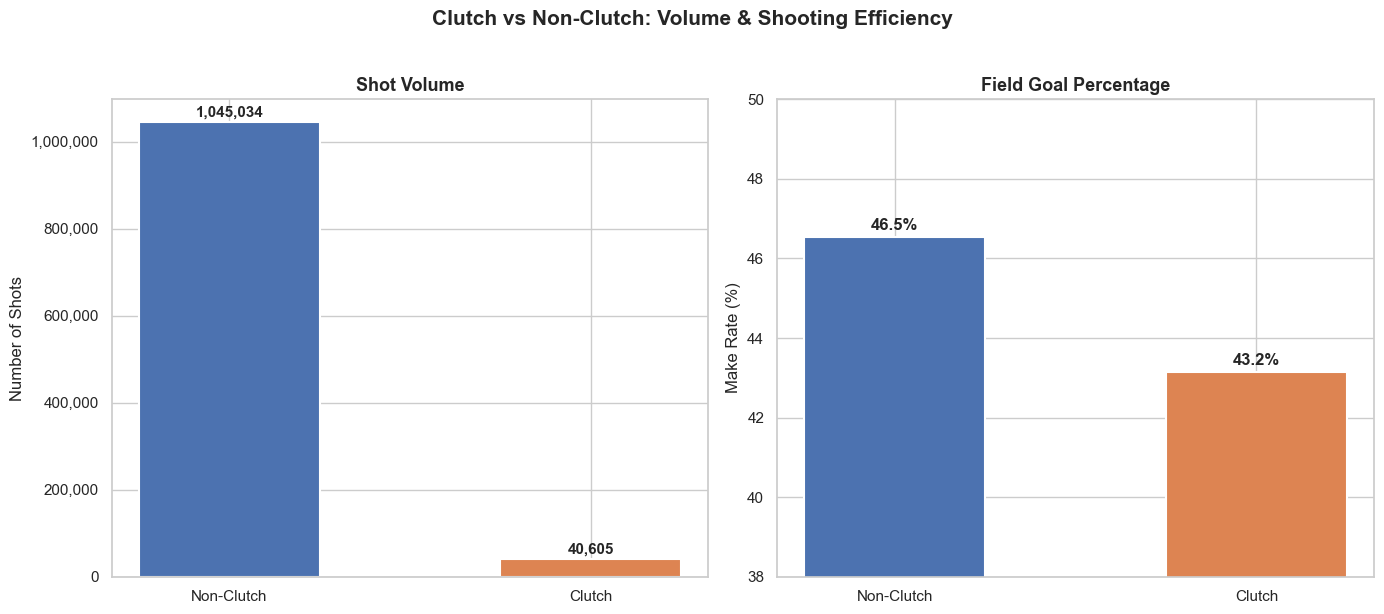

✅ Chart 1 & 2 saved


In [20]:
# ============================================================
# Phase 4: EDA — Chart 1 & 2
# Clutch shot volume and make rate comparison
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Clutch vs Non-Clutch: Volume & Shooting Efficiency',
             fontsize=15, fontweight='bold', y=1.02)

# ── Chart 1: Shot Volume ──────────────────────────────────
labels = ['Non-Clutch', 'Clutch']
counts = [
    shots_df[shots_df['is_clutch'] == 0].shape[0],
    shots_df[shots_df['is_clutch'] == 1].shape[0]
]
colors = ['#4C72B0', '#DD8452']

bars = axes[0].bar(labels, counts, color=colors, edgecolor='white',
                   linewidth=1.5, width=0.5)
axes[0].set_title('Shot Volume', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Shots')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Add value labels on bars
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                f'{count:,}', ha='center', va='bottom',
                fontweight='bold', fontsize=11)

# ── Chart 2: Make Rate ────────────────────────────────────
make_rates = [
    shots_df[shots_df['is_clutch'] == 0]['shot_made'].mean() * 100,
    shots_df[shots_df['is_clutch'] == 1]['shot_made'].mean() * 100
]

bars2 = axes[1].bar(labels, make_rates, color=colors, edgecolor='white',
                    linewidth=1.5, width=0.5)
axes[1].set_title('Field Goal Percentage', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Make Rate (%)')
axes[1].set_ylim(38, 50)

# Add value labels
for bar, rate in zip(bars2, make_rates):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{rate:.1f}%', ha='center', va='bottom',
                fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('chart1_clutch_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 1 & 2 saved")

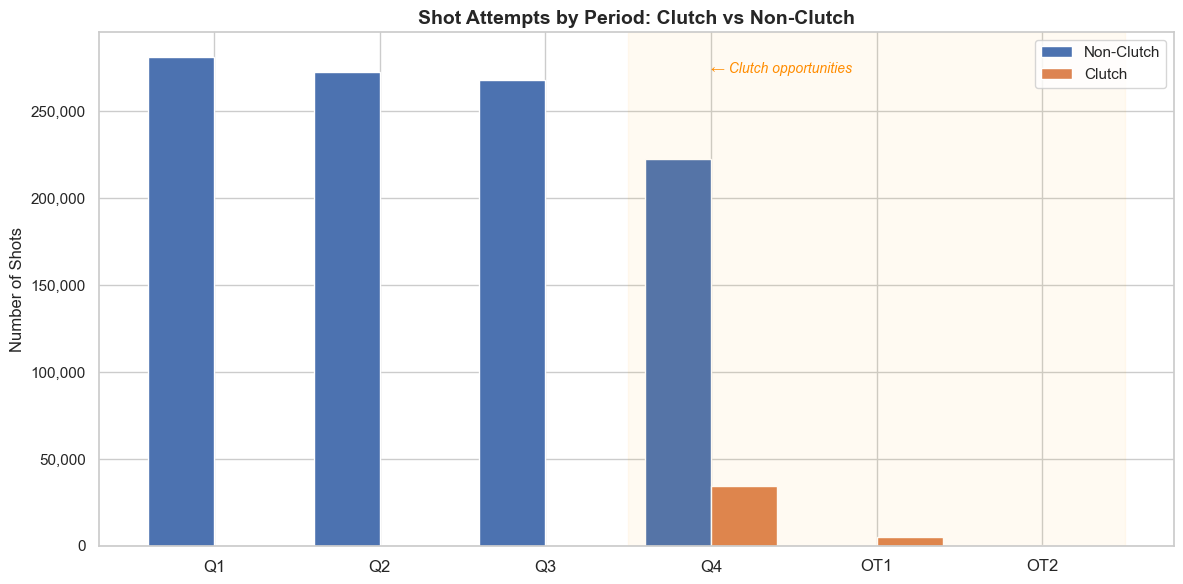

✅ Chart 3 saved


In [21]:
# ============================================================
# Chart 3: Shot attempts by period
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

period_data = shots_df.groupby(['period', 'is_clutch']).size().unstack(fill_value=0)
period_data.columns = ['Non-Clutch', 'Clutch']

# Only show periods 1-6 (covers OT)
period_data = period_data[period_data.index <= 6]

x = range(len(period_data))
width = 0.4

bars1 = ax.bar([i - width/2 for i in x], period_data['Non-Clutch'],
               width, label='Non-Clutch', color='#4C72B0', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], period_data['Clutch'],
               width, label='Clutch', color='#DD8452', edgecolor='white')

period_labels = {1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4', 5: 'OT1', 6: 'OT2'}
ax.set_xticks(list(x))
ax.set_xticklabels([period_labels.get(p, f'OT{p-4}')
                    for p in period_data.index], fontsize=12)

ax.set_title('Shot Attempts by Period: Clutch vs Non-Clutch',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Shots')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=11)

# Highlight Q4 and OT
ax.axvspan(2.5, len(period_data) - 0.5, alpha=0.05,
           color='orange', label='Pressure Periods')
ax.text(3.0, ax.get_ylim()[1] * 0.92, '← Clutch opportunities',
        fontsize=10, color='darkorange', style='italic')

plt.tight_layout()
plt.savefig('chart2_shots_by_period.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved")

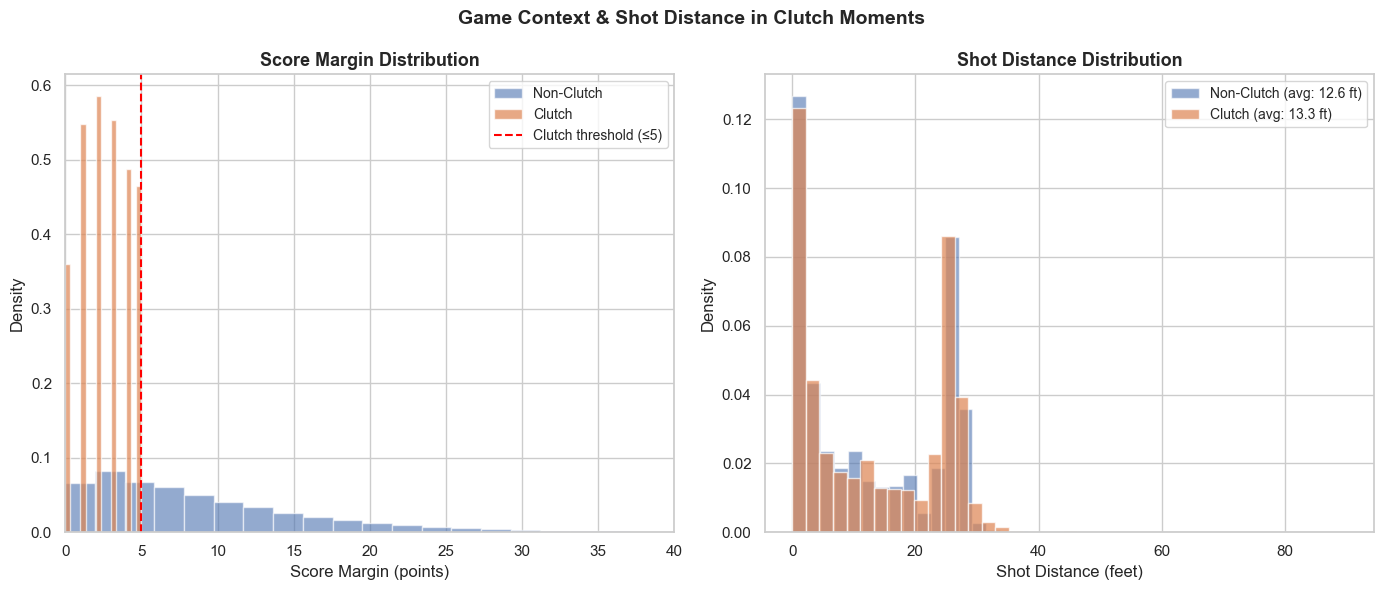

✅ Chart 4 & 5 saved


In [22]:
# ============================================================
# Chart 4 & 5: Score margin distribution + shot distance
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Game Context & Shot Distance in Clutch Moments',
             fontsize=14, fontweight='bold')

# ── Chart 4: Score margin distribution ───────────────────
clutch_margins = shots_df[shots_df['is_clutch'] == 1]['score_margin']
non_clutch_margins = shots_df[shots_df['is_clutch'] == 0]['score_margin']

axes[0].hist(non_clutch_margins, bins=40, alpha=0.6, color='#4C72B0',
             label='Non-Clutch', density=True)
axes[0].hist(clutch_margins, bins=15, alpha=0.7, color='#DD8452',
             label='Clutch', density=True)
axes[0].axvline(x=5, color='red', linestyle='--', linewidth=1.5,
                label='Clutch threshold (≤5)')
axes[0].set_title('Score Margin Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Score Margin (points)')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=10)
axes[0].set_xlim(0, 40)

# ── Chart 5: Shot distance ────────────────────────────────
clutch_dist = shots_df[shots_df['is_clutch'] == 1]['dist']
non_clutch_dist = shots_df[shots_df['is_clutch'] == 0]['dist']

axes[1].hist(non_clutch_dist, bins=40, alpha=0.6, color='#4C72B0',
             label=f'Non-Clutch (avg: {non_clutch_dist.mean():.1f} ft)',
             density=True)
axes[1].hist(clutch_dist, bins=40, alpha=0.7, color='#DD8452',
             label=f'Clutch (avg: {clutch_dist.mean():.1f} ft)',
             density=True)
axes[1].set_title('Shot Distance Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Shot Distance (feet)')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('chart3_context_and_distance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 4 & 5 saved")

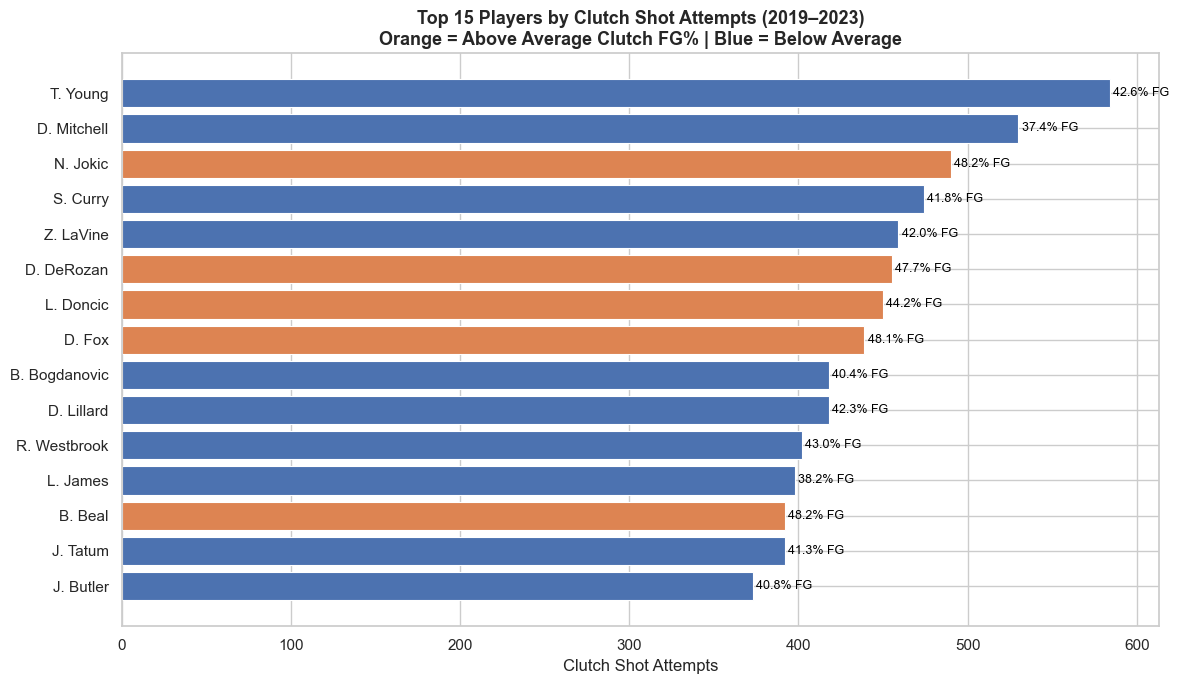


✅ Chart 6 saved

Top 10 Clutch Players (by attempts):
       player  clutch_attempts  clutch_makes  clutch_fg_pct
     T. Young              584           249      42.636986
  D. Mitchell              530           198      37.358491
     N. Jokic              490           236      48.163265
     S. Curry              474           198      41.772152
    Z. LaVine              459           193      42.047930
   D. DeRozan              455           217      47.692308
    L. Doncic              450           199      44.222222
       D. Fox              439           211      48.063781
B. Bogdanovic              418           169      40.430622
   D. Lillard              418           177      42.344498


In [23]:
# ============================================================
# Chart 6: Top clutch players by attempts + efficiency
# ============================================================

# Get players with at least 30 clutch attempts (meaningful sample)
clutch_players = (
    shots_df[shots_df['is_clutch'] == 1]
    .groupby('player')
    .agg(
        clutch_attempts = ('shot_made', 'count'),
        clutch_makes    = ('shot_made', 'sum')
    )
    .reset_index()
)

clutch_players['clutch_fg_pct'] = (
    clutch_players['clutch_makes'] / clutch_players['clutch_attempts'] * 100
)

# Filter: at least 30 attempts for credibility
qualified = clutch_players[clutch_players['clutch_attempts'] >= 30]
top_volume = qualified.nlargest(15, 'clutch_attempts')

fig, ax = plt.subplots(figsize=(12, 7))

colors_bar = ['#DD8452' if pct >= 43.2 else '#4C72B0'
              for pct in top_volume['clutch_fg_pct']]

bars = ax.barh(top_volume['player'], top_volume['clutch_attempts'],
               color=colors_bar, edgecolor='white', linewidth=0.8)

# Add FG% labels
for bar, (_, row) in zip(bars, top_volume.iterrows()):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f"{row['clutch_fg_pct']:.1f}% FG",
            va='center', fontsize=9, color='black')

ax.set_title('Top 15 Players by Clutch Shot Attempts (2019–2023)\n'
             'Orange = Above Average Clutch FG% | Blue = Below Average',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Clutch Shot Attempts')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('chart4_top_clutch_players.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Chart 6 saved")
print("\nTop 10 Clutch Players (by attempts):")
print(top_volume[['player', 'clutch_attempts', 'clutch_makes',
                  'clutch_fg_pct']].head(10).to_string(index=False))

In [24]:
# ============================================================
# Phase 5: Feature Engineering
# ============================================================

print("Building features...")

# ── Feature 1: Is it a 3-pointer? ────────────────────────
# 3PT shots in clutch are game-changers — worth tracking
shots_df['is_3pt'] = shots_df['subtype'].str.contains(
    '3PT|3-pointer|Three', case=False, na=False).astype(int)

print(f"✅ is_3pt: {shots_df['is_3pt'].sum():,} three-point attempts")

# ── Feature 2: Is it a paint shot? ───────────────────────
# Shots within 5 feet = high percentage attempts
shots_df['is_paint'] = (shots_df['dist'] <= 5).astype(int)

print(f"✅ is_paint: {shots_df['is_paint'].sum():,} paint shots")

# ── Feature 3: Time pressure score ───────────────────────
# Inverted seconds — higher number = more pressure
# We normalize to 0-1 scale (0 = start of period, 1 = buzzer)
shots_df['time_pressure'] = 1 - (shots_df['seconds_remaining'] / 720)

print(f"✅ time_pressure: range "
      f"{shots_df['time_pressure'].min():.2f} - "
      f"{shots_df['time_pressure'].max():.2f}")

# ── Feature 4: Period pressure ────────────────────────────
# Q4=1, OT=2, OT2=3 etc. Early quarters = 0
shots_df['period_pressure'] = (shots_df['period'] - 3).clip(lower=0)

print(f"✅ period_pressure distribution:")
print(shots_df['period_pressure'].value_counts().sort_index().to_string())

# ── Feature 5: Player overall FG% (career in our dataset) ─
# This captures each player's baseline shooting skill
player_fg = (
    shots_df.groupby('player')['shot_made']
    .mean()
    .rename('player_overall_fg')
    .reset_index()
)

shots_df = shots_df.merge(player_fg, on='player', how='left')
print(f"\n✅ player_overall_fg: avg = {shots_df['player_overall_fg'].mean():.3f}")

# ── Feature 6: Player clutch attempt count ────────────────
# Players with more clutch experience may handle pressure better
player_clutch_exp = (
    shots_df[shots_df['is_clutch'] == 1]
    .groupby('player')['shot_made']
    .count()
    .rename('player_clutch_attempts')
    .reset_index()
)

shots_df = shots_df.merge(player_clutch_exp, on='player', how='left')
shots_df['player_clutch_attempts'] = shots_df['player_clutch_attempts'].fillna(0)
print(f"✅ player_clutch_attempts: avg = {shots_df['player_clutch_attempts'].mean():.1f}")

# ── Feature 7: Shot type encoded ─────────────────────────
# Convert shot subtype to numeric categories
shot_type_map = {
    'Jump Shot': 0,
    'Layup Shot': 1,
    'Dunk Shot': 2,
    'Hook Shot': 3,
    'Driving Layup Shot': 4,
    'Step Back Jump Shot': 5,
    'Pullup Jump shot': 6,
    'Fadeaway Jump Shot': 7,
    'Turnaround Jump Shot': 8,
    'Floating Jump shot': 9,
}

shots_df['shot_type_encoded'] = (
    shots_df['subtype']
    .map(shot_type_map)
    .fillna(99)  # 99 = "other"
    .astype(int)
)

print(f"✅ shot_type_encoded: {shots_df['shot_type_encoded'].nunique()} categories")

print(f"\n{'='*45}")
print(f"  FEATURE ENGINEERING COMPLETE")
print(f"{'='*45}")
print(f"Total columns now: {shots_df.shape[1]}")
print(f"Total rows: {shots_df.shape[0]:,}")

Building features...
✅ is_3pt: 0 three-point attempts
✅ is_paint: 445,099 paint shots
✅ time_pressure: range 0.00 - 1.00
✅ period_pressure distribution:
period_pressure
0    821814
1    257162
2      5854
3       678
4        97
5        34

✅ player_overall_fg: avg = 0.464
✅ player_clutch_attempts: avg = 153.2
✅ shot_type_encoded: 10 categories

  FEATURE ENGINEERING COMPLETE
Total columns now: 24
Total rows: 1,085,639


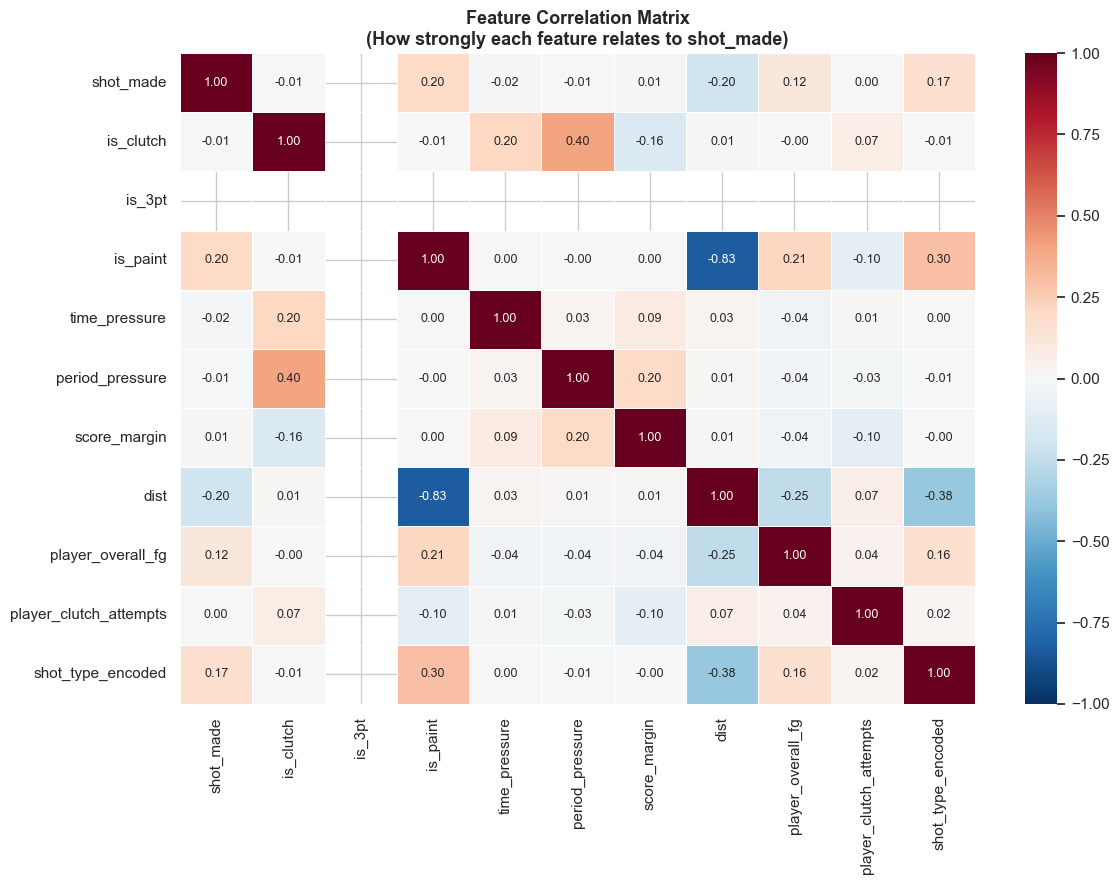

✅ Correlation matrix saved


In [25]:
# ============================================================
# Visualize feature correlations with shot_made
# ============================================================

feature_cols = [
    'shot_made', 'is_clutch', 'is_3pt', 'is_paint',
    'time_pressure', 'period_pressure', 'score_margin',
    'dist', 'player_overall_fg', 'player_clutch_attempts',
    'shot_type_encoded'
]

corr_matrix = shots_df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # Hide upper triangle

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    ax=ax,
    linewidths=0.5,
    annot_kws={'size': 9}
)

ax.set_title('Feature Correlation Matrix\n(How strongly each feature relates to shot_made)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart5_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Correlation matrix saved")

In [26]:
# ============================================================
# Save the fully engineered dataset
# ============================================================

shots_df.to_csv("shots_engineered.csv", index=False)

print("✅ Saved to shots_engineered.csv")
print(f"   {shots_df.shape[0]:,} rows | {shots_df.shape[1]} columns")
print(f"\nFinal feature list:")
for col in shots_df.columns:
    print(f"  • {col}")

✅ Saved to shots_engineered.csv
   1,085,639 rows | 24 columns

Final feature list:
  • gameid
  • period
  • clock
  • h_pts
  • a_pts
  • team
  • player
  • type
  • subtype
  • dist
  • x
  • y
  • season
  • shot_made
  • score_margin
  • seconds_remaining
  • is_clutch
  • is_3pt
  • is_paint
  • time_pressure
  • period_pressure
  • player_overall_fg
  • player_clutch_attempts
  • shot_type_encoded


In [28]:
# ============================================================
# Fix is_3pt using shot distance instead of subtype
# 3-point line: 22ft corners, 23.75ft everywhere else
# We'll use 22ft as conservative threshold
# ============================================================

shots_df['is_3pt'] = (shots_df['dist'] >= 22).astype(int)

print(f"✅ is_3pt fixed!")
print(f"   3PT attempts: {shots_df['is_3pt'].sum():,}")
print(f"   2PT attempts: {(shots_df['is_3pt']==0).sum():,}")
print(f"   3PT rate: {shots_df['is_3pt'].mean():.1%}")

print(f"\n3PT make rate: {shots_df[shots_df['is_3pt']==1]['shot_made'].mean():.1%}")
print(f"2PT make rate: {shots_df[shots_df['is_3pt']==0]['shot_made'].mean():.1%}")

# Verify clutch 3PT attempts
clutch_3pt = shots_df[(shots_df['is_clutch']==1) & (shots_df['is_3pt']==1)]
print(f"\nClutch 3PT attempts: {len(clutch_3pt):,}")

✅ is_3pt fixed!
   3PT attempts: 360,575
   2PT attempts: 725,064
   3PT rate: 33.2%

3PT make rate: 35.3%
2PT make rate: 51.9%

Clutch 3PT attempts: 14,571


In [29]:
# ============================================================
# Re-save with fixed is_3pt
# ============================================================

shots_df.to_csv("shots_engineered.csv", index=False)
print("✅ shots_engineered.csv updated with fixed is_3pt")

✅ shots_engineered.csv updated with fixed is_3pt


In [30]:
# ============================================================
# Phase 6: Modeling — Prepare Data
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)

print("Preparing model data...")

# ── Define features and target ────────────────────────────
FEATURES = [
    'is_3pt',               # Shot type: 3 or 2 pointer
    'is_paint',             # Close range shot
    'dist',                 # Exact shot distance
    'time_pressure',        # How late in the period
    'period_pressure',      # Q4/OT pressure
    'score_margin',         # How close the game is
    'player_overall_fg',    # Player's baseline skill
    'player_clutch_attempts', # Clutch experience
    'shot_type_encoded',    # Type of shot
    'is_clutch',            # Is this a clutch moment
]

TARGET = 'shot_made'

# Drop any remaining nulls in our feature columns
model_df = shots_df[FEATURES + [TARGET, 'player', 'season']].dropna()

print(f"✅ Model dataset: {model_df.shape[0]:,} rows")
print(f"   Features: {len(FEATURES)}")
print(f"   Target: {TARGET}")
print(f"\nClass balance:")
print(model_df[TARGET].value_counts())
print(f"Make rate: {model_df[TARGET].mean():.1%}")

Preparing model data...
✅ Model dataset: 1,085,639 rows
   Features: 10
   Target: shot_made

Class balance:
shot_made
0    581735
1    503904
Name: count, dtype: int64
Make rate: 46.4%


In [31]:
# ============================================================
# Split data — train on 2019-2022, test on 2023
# (Time-based split = more realistic than random)
# ============================================================

train_df = model_df[model_df['season'] != '2023']
test_df  = model_df[model_df['season'] == '2023']

X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_test = test_df[FEATURES]
y_test = test_df[TARGET]

print(f"✅ Time-based split:")
print(f"   Train: {len(X_train):,} shots (2019–2022)")
print(f"   Test:  {len(X_test):,} shots (2023)")
print(f"\nTrain make rate: {y_train.mean():.1%}")
print(f"Test make rate:  {y_test.mean():.1%}")

# ── Scale features for Logistic Regression ────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\n✅ Features scaled for Logistic Regression")

✅ Time-based split:
   Train: 852,904 shots (2019–2022)
   Test:  232,735 shots (2023)

Train make rate: 46.1%
Test make rate:  47.4%

✅ Features scaled for Logistic Regression


In [32]:
# ============================================================
# Model 1: Logistic Regression — Simple & Explainable
# ============================================================

print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Predictions
lr_preds = lr_model.predict(X_test_scaled)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
lr_accuracy = accuracy_score(y_test, lr_preds)
lr_auc      = roc_auc_score(y_test, lr_probs)

print(f"\n{'='*40}")
print(f"  LOGISTIC REGRESSION RESULTS")
print(f"{'='*40}")
print(f"  Accuracy:  {lr_accuracy:.1%}")
print(f"  ROC-AUC:   {lr_auc:.4f}")
print(f"{'='*40}")
print(f"\nDetailed Report:")
print(classification_report(y_test, lr_preds,
      target_names=['Missed', 'Made']))

# Feature importance (coefficients)
coef_df = pd.DataFrame({
    'feature': FEATURES,
    'coefficient': lr_model.coef_[0]
}).sort_values('coefficient', ascending=False)

print("\nFeature Coefficients (positive = helps make shot):")
print(coef_df.to_string(index=False))

Training Logistic Regression...

  LOGISTIC REGRESSION RESULTS
  Accuracy:  60.8%
  ROC-AUC:   0.6353

Detailed Report:
              precision    recall  f1-score   support

      Missed       0.61      0.69      0.65    122341
        Made       0.60      0.51      0.55    110394

    accuracy                           0.61    232735
   macro avg       0.61      0.60      0.60    232735
weighted avg       0.61      0.61      0.60    232735


Feature Coefficients (positive = helps make shot):
               feature  coefficient
     shot_type_encoded     0.230332
              is_paint     0.168978
     player_overall_fg     0.129610
                is_3pt     0.102005
          score_margin     0.034808
player_clutch_attempts     0.033907
             is_clutch    -0.006806
       period_pressure    -0.017527
         time_pressure    -0.029612
                  dist    -0.240628


In [33]:
# ============================================================
# Model 2: Random Forest — More Powerful
# ============================================================

print("Training Random Forest (this may take 1-2 minutes)...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1        # Use all CPU cores
)
rf_model.fit(X_train, y_train)  # RF doesn't need scaled data

# Predictions
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# Metrics
rf_accuracy = accuracy_score(y_test, rf_preds)
rf_auc      = roc_auc_score(y_test, rf_probs)

print(f"\n{'='*40}")
print(f"  RANDOM FOREST RESULTS")
print(f"{'='*40}")
print(f"  Accuracy:  {rf_accuracy:.1%}")
print(f"  ROC-AUC:   {rf_auc:.4f}")
print(f"{'='*40}")
print(f"\nDetailed Report:")
print(classification_report(y_test, rf_preds,
      target_names=['Missed', 'Made']))

# Feature importance
feat_imp = pd.DataFrame({
    'feature': FEATURES,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importances (higher = more useful to model):")
print(feat_imp.to_string(index=False))

Training Random Forest (this may take 1-2 minutes)...

  RANDOM FOREST RESULTS
  Accuracy:  62.5%
  ROC-AUC:   0.6585

Detailed Report:
              precision    recall  f1-score   support

      Missed       0.60      0.83      0.70    122341
        Made       0.68      0.40      0.50    110394

    accuracy                           0.63    232735
   macro avg       0.64      0.61      0.60    232735
weighted avg       0.64      0.63      0.61    232735


Feature Importances (higher = more useful to model):
               feature  importance
                  dist    0.381032
     shot_type_encoded    0.268812
              is_paint    0.182299
                is_3pt    0.064879
     player_overall_fg    0.051510
         time_pressure    0.030992
player_clutch_attempts    0.009791
          score_margin    0.008940
       period_pressure    0.001294
             is_clutch    0.000450


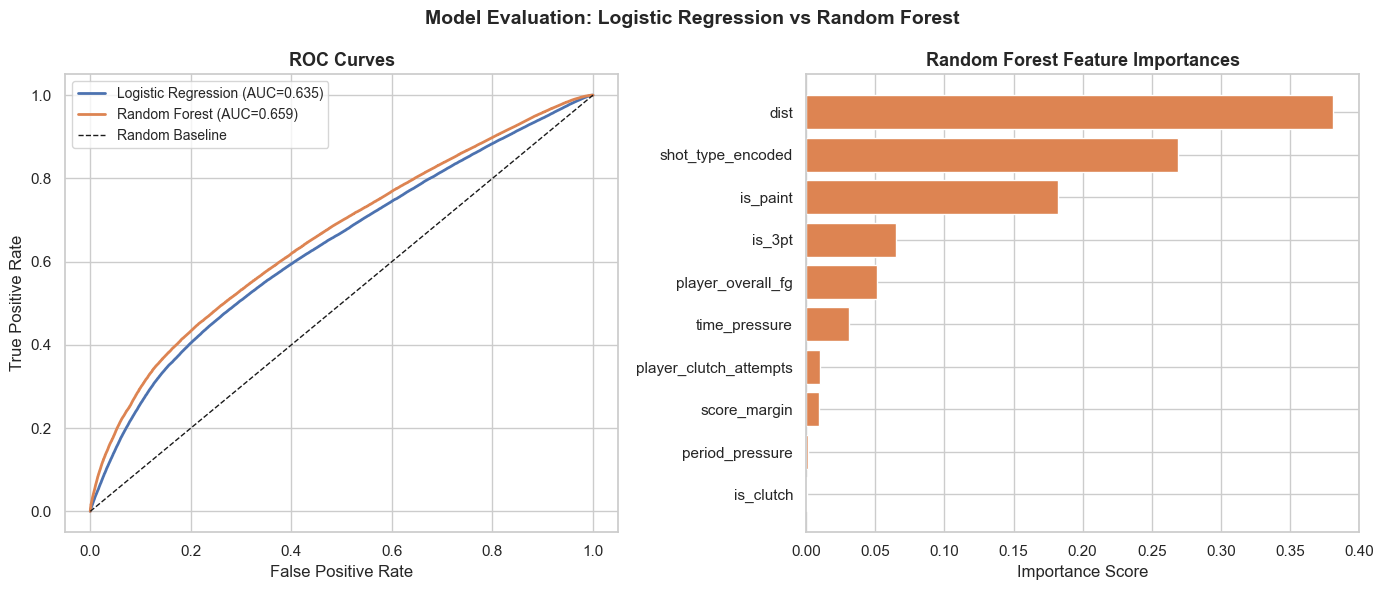

✅ Model comparison chart saved


In [34]:
# ============================================================
# Visual comparison: ROC curves + Feature importance
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model Evaluation: Logistic Regression vs Random Forest',
             fontsize=14, fontweight='bold')

# ── ROC Curves ────────────────────────────────────────────
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

axes[0].plot(fpr_lr, tpr_lr, color='#4C72B0', linewidth=2,
             label=f'Logistic Regression (AUC={lr_auc:.3f})')
axes[0].plot(fpr_rf, tpr_rf, color='#DD8452', linewidth=2,
             label=f'Random Forest (AUC={rf_auc:.3f})')
axes[0].plot([0,1], [0,1], 'k--', linewidth=1, label='Random Baseline')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)

# ── Feature Importances (RF) ──────────────────────────────
feat_imp_sorted = feat_imp.sort_values('importance')
axes[1].barh(feat_imp_sorted['feature'],
             feat_imp_sorted['importance'],
             color='#DD8452', edgecolor='white')
axes[1].set_title('Random Forest Feature Importances',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('chart6_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Model comparison chart saved")

In [35]:
# ============================================================
# Phase 7: Who are the truly clutch players?
# Compare actual makes vs model-expected makes in clutch spots
# ============================================================

# Get all clutch shots from the test set (2023 season)
clutch_test = test_df[test_df['is_clutch'] == 1].copy()
clutch_test['predicted_prob'] = rf_model.predict_proba(
    clutch_test[FEATURES])[:, 1]

# For each player: actual makes vs expected makes
clutch_summary = (
    clutch_test.groupby('player')
    .agg(
        clutch_attempts  = ('shot_made', 'count'),
        actual_makes     = ('shot_made', 'sum'),
        expected_makes   = ('predicted_prob', 'sum')
    )
    .reset_index()
)

# Shooting percentage
clutch_summary['actual_fg_pct'] = (
    clutch_summary['actual_makes'] /
    clutch_summary['clutch_attempts'] * 100
)
clutch_summary['expected_fg_pct'] = (
    clutch_summary['expected_makes'] /
    clutch_summary['clutch_attempts'] * 100
)

# Clutch Score = how much they outperform expectations
clutch_summary['clutch_score'] = (
    clutch_summary['actual_fg_pct'] -
    clutch_summary['expected_fg_pct']
)

# Filter: minimum 15 clutch attempts for credibility
qualified = clutch_summary[
    clutch_summary['clutch_attempts'] >= 15
].copy()

print(f"✅ Players with 15+ clutch attempts in 2023: {len(qualified)}")
print(f"\nTop 10 Most Clutch Players (outperform expectations most):")
top_clutch = qualified.nlargest(10, 'clutch_score')
print(top_clutch[['player', 'clutch_attempts', 'actual_fg_pct',
                   'expected_fg_pct', 'clutch_score'
                   ]].to_string(index=False))

print(f"\nBottom 10 Least Clutch Players (underperform most):")
bottom_clutch = qualified.nsmallest(10, 'clutch_score')
print(bottom_clutch[['player', 'clutch_attempts', 'actual_fg_pct',
                      'expected_fg_pct', 'clutch_score'
                      ]].to_string(index=False))

✅ Players with 15+ clutch attempts in 2023: 173

Top 10 Most Clutch Players (outperform expectations most):
       player  clutch_attempts  actual_fg_pct  expected_fg_pct  clutch_score
    A. Reaves               27      62.962963        39.159727     23.803236
    C. Sexton               18      72.222222        52.765983     19.456239
   W. Kessler               16      87.500000        68.303704     19.196296
       D. Lee               20      60.000000        42.366919     17.633081
    C. Thomas               21      61.904762        44.505269     17.399493
    O. Agbaji               22      54.545455        37.490687     17.054768
    E. Mobley               34      67.647059        52.744103     14.902956
     N. Batum               30      50.000000        36.260296     13.739704
    D. Hunter               31      54.838710        41.407586     13.431124
T. Murphy III               20      50.000000        37.006779     12.993221

Bottom 10 Least Clutch Players (underperform

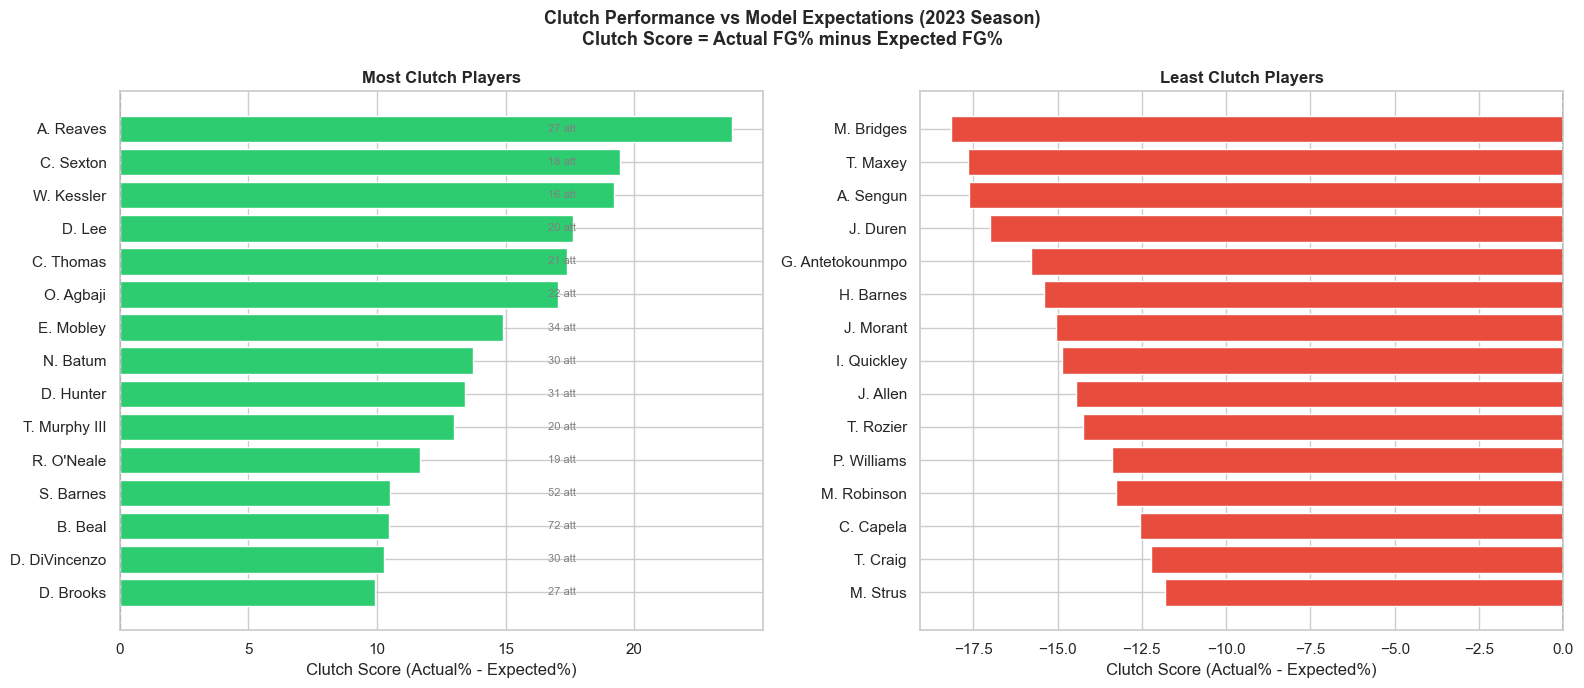

✅ Clutch rankings chart saved


In [36]:
# ============================================================
# Visualize: Clutch Score for top and bottom players
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Clutch Performance vs Model Expectations (2023 Season)\n'
             'Clutch Score = Actual FG% minus Expected FG%',
             fontsize=13, fontweight='bold')

# ── Top 15 Clutch Performers ──────────────────────────────
top15 = qualified.nlargest(15, 'clutch_score')
colors_top = ['#2ecc71' if x > 0 else '#e74c3c'
              for x in top15['clutch_score']]

axes[0].barh(top15['player'], top15['clutch_score'],
             color=colors_top, edgecolor='white')
axes[0].axvline(x=0, color='black', linewidth=1.2, linestyle='--')
axes[0].set_title('Most Clutch Players', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Clutch Score (Actual% - Expected%)')
axes[0].invert_yaxis()

# Add attempt count labels
for i, (_, row) in enumerate(top15.iterrows()):
    axes[0].text(top15['clutch_score'].max() * 0.7,
                i, f"{int(row['clutch_attempts'])} att",
                va='center', fontsize=8, color='gray')

# ── Bottom 15 Clutch Performers ───────────────────────────
bottom15 = qualified.nsmallest(15, 'clutch_score').sort_values(
    'clutch_score')
colors_bot = ['#2ecc71' if x > 0 else '#e74c3c'
              for x in bottom15['clutch_score']]

axes[1].barh(bottom15['player'], bottom15['clutch_score'],
             color=colors_bot, edgecolor='white')
axes[1].axvline(x=0, color='black', linewidth=1.2, linestyle='--')
axes[1].set_title('Least Clutch Players', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Clutch Score (Actual% - Expected%)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('chart7_clutch_rankings.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Clutch rankings chart saved")

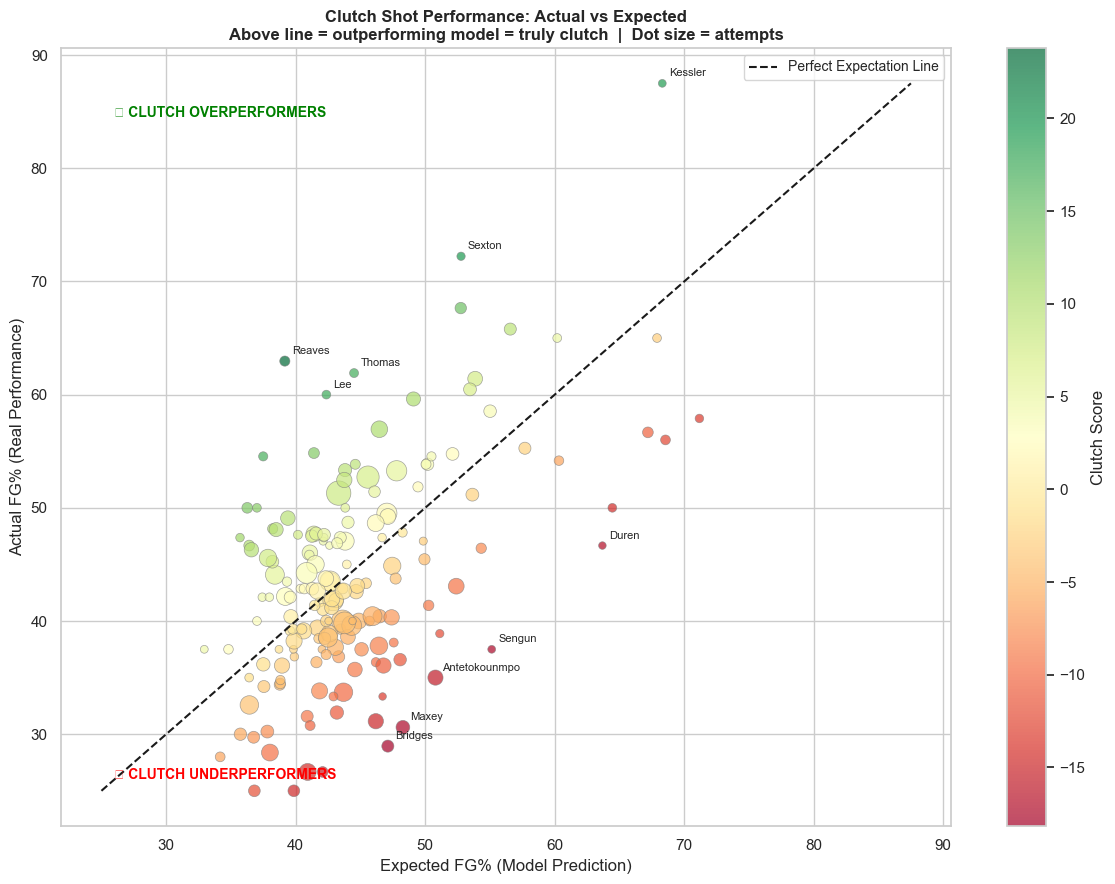

✅ Scatter plot saved


In [38]:
# ============================================================
# Scatter: Actual FG% vs Expected FG% in clutch spots
# ============================================================

fig, ax = plt.subplots(figsize=(12, 9))

scatter = ax.scatter(
    qualified['expected_fg_pct'],
    qualified['actual_fg_pct'],
    c=qualified['clutch_score'],
    cmap='RdYlGn',
    s=qualified['clutch_attempts'] * 2,
    alpha=0.7,
    edgecolors='gray',
    linewidth=0.5
)

# Perfect prediction line
min_val = min(qualified['expected_fg_pct'].min(),
              qualified['actual_fg_pct'].min())
max_val = max(qualified['expected_fg_pct'].max(),
              qualified['actual_fg_pct'].max())
ax.plot([min_val, max_val], [min_val, max_val],
        'k--', linewidth=1.5, label='Perfect Expectation Line')

# ── FIXED: use pd.concat instead of .append ───────────────
notable = pd.concat([
    qualified.nlargest(5, 'clutch_score'),
    qualified.nsmallest(5, 'clutch_score')
])

for _, row in notable.iterrows():
    ax.annotate(
        row['player'].split(' ')[-1],
        (row['expected_fg_pct'], row['actual_fg_pct']),
        fontsize=8,
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.colorbar(scatter, label='Clutch Score')
ax.set_xlabel('Expected FG% (Model Prediction)', fontsize=12)
ax.set_ylabel('Actual FG% (Real Performance)', fontsize=12)
ax.set_title('Clutch Shot Performance: Actual vs Expected\n'
             'Above line = outperforming model = truly clutch  |  '
             'Dot size = attempts',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.text(min_val + 1, max_val - 3, '⬆ CLUTCH OVERPERFORMERS',
        color='green', fontsize=10, fontweight='bold')
ax.text(min_val + 1, min_val + 1, '⬇ CLUTCH UNDERPERFORMERS',
        color='red', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('chart8_actual_vs_expected.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Scatter plot saved")